<div style="background:linear-gradient(120deg,#4F46E5,#7E22CE);color:#fff;
padding:28px 32px;border-radius:14px;font-family:'IBM Plex Sans',Segoe UI,sans-serif">
<div style="font-family:'IBM Plex Mono',Consolas,monospace;font-size:0.8rem;opacity:.85;
letter-spacing:.1em">INF672 · MACHINE LEARNING · GL07</div>
<h1 style="margin:6px 0 2px 0;font-size:1.9rem;font-weight:700">Preprocesamiento de datos</h1>
<div style="opacity:.9">Tratamiento de faltantes · Codificación categórica · Escalado y normalización · Pipelines</div>
</div>

## Objetivos

Al terminar este cuaderno serás capaz de:

1. **Diagnosticar** valores faltantes e identificar su *mecanismo* (MCAR, MAR, estructural), y elegir la estrategia de imputación adecuada.
2. **Codificar** variables categóricas nominales y ordinales, distinguiendo cuándo usar `OneHotEncoder`, `OrdinalEncoder` o *frequency encoding*.
3. **Escalar y normalizar** variables numéricas y decidir entre `StandardScaler`, `MinMaxScaler` y `RobustScaler` según la presencia de *outliers*.
4. **Componer** todo lo anterior en un `Pipeline` con `ColumnTransformer`, evitando fuga de datos (*data leakage*).

### El dataset — `solicitudes_credito.csv`

800 solicitudes de crédito. La variable objetivo es `aprobado` (1 = aprobado, 0 = rechazado).

<div style="border-left:4px solid #6B7280;background:#F9FAFB;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#6B7280;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Nota · Requisito</div><div style="color:#111827;margin-top:4px">Coloca `solicitudes_credito.csv` en la misma carpeta que este cuaderno antes de ejecutar.</div></div>

## 0 · Preparación del entorno

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Paleta "cuaderno científico" para los gráficos
INDIGO, PURPURA, CORAL = "#4F46E5", "#7E22CE", "#F43F5E"

df = pd.read_csv("solicitudes_credito.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (800, 17)


,id_solicitud,edad,genero,estado_civil,nivel_educacion,ciudad,tipo_empleo,antiguedad_laboral_meses,ingreso_mensual_bs,monto_solicitado_bs,plazo_meses,num_dependientes,puntaje_crediticio,tiene_vivienda_propia,historial_mora,nivel_riesgo,aprobado
0,1000,22,Femenino,Casado,Licenciatura,Riberalta,Dependiente,472.0,10838.0,101057.0,24,4,NaN,Sí,No,Bajo,1
1,1001,59,Masculino,CASADO,Técnico,Santa Cruz,Dependiente,255.0,7129.0,18173.0,12,5,714.0,No,Sí,Alto,0
2,1002,52,Masculino,Divorciado,Posgrado,La Paz,Independiente,197.0,NaN,36325.0,6,5,687.0,No,Sí,Alto,0
3,1003,41,Femenino,CASADO,Licenciatura,Cochabamba,Dependiente,32.0,10818.0,34379.0,24,5,686.0,Sí,No,Bajo,1
4,1004,40,Masculino,NaN,Secundaria,La Paz,Jubilado,362.0,6276.0,72416.0,36,3,631.0,Sí,No,Bajo,0


### Radiografía inicial

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_solicitud              800 non-null    int64  
 1   edad                      800 non-null    int64  
 2   genero                    800 non-null    str    
 3   estado_civil              776 non-null    str    
 4   nivel_educacion           800 non-null    str    
 5   ciudad                    800 non-null    str    
 6   tipo_empleo               800 non-null    str    
 7   antiguedad_laboral_meses  741 non-null    float64
 8   ingreso_mensual_bs        683 non-null    float64
 9   monto_solicitado_bs       800 non-null    float64
 10  plazo_meses               800 non-null    int64  
 11  num_dependientes          800 non-null    int64  
 12  puntaje_crediticio        733 non-null    float64
 13  tiene_vivienda_propia     800 non-null    str    
 14  historial_mora       

In [22]:
# Resumen estadístico de las variables numéricas
df.describe().round(1)

,id_solicitud,edad,antiguedad_laboral_meses,ingreso_mensual_bs,monto_solicitado_bs,plazo_meses,num_dependientes,puntaje_crediticio,aprobado
count,800.0,800.0,741.0,683.0,800.0,800.0,800.0,733.0,800.0
mean,1399.5,44.4,254.6,9683.4,57746.4,24.9,3.0,652.8,0.4
std,231.1,15.2,137.1,18617.5,54732.1,13.8,2.0,92.6,0.5
min,1000.0,18.0,1.0,800.0,3044.0,6.0,0.0,332.0,0.0
25%,1199.8,31.0,138.0,4882.0,25477.0,12.0,1.0,597.0,0.0
50%,1399.5,44.0,268.0,7156.0,46436.0,24.0,3.0,655.0,0.0
75%,1599.2,58.0,371.0,9639.5,71922.8,36.0,5.0,716.0,1.0
max,1799.0,70.0,480.0,185877.0,400000.0,60.0,6.0,850.0,1.0


<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 0.1 · Primer diagnóstico</div><div style="color:#111827;margin-top:4px">Antes de tocar nada: ¿cuántos valores faltan por columna (en cantidad y en %)? ¿Qué columnas categóricas tienen valores <em>inconsistentes</em> (mayúsculas/espacios)?</div></div>

**Solución**

In [23]:
faltantes = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().mean()*100).round(1)
})
faltantes[faltantes["n_faltantes"] > 0].sort_values("pct_faltantes", ascending=False)

,n_faltantes,pct_faltantes
ingreso_mensual_bs,117,14.6
puntaje_crediticio,67,8.4
antiguedad_laboral_meses,59,7.4
estado_civil,24,3.0


In [24]:
# Categóricas sospechosas: mismos valores escritos de formas distintas
print("tiene_vivienda_propia:", sorted(df["tiene_vivienda_propia"].dropna().unique()))
print("estado_civil        :", sorted(df["estado_civil"].dropna().unique()))

tiene_vivienda_propia: ['NO', 'No', 'Sí', 'si']
estado_civil        : [' CASADO', ' DIVORCIADO', ' SOLTERO', ' UNIÓN LIBRE', ' VIUDO', 'Casado', 'Divorciado', 'Soltero', 'Unión Libre', 'Viudo']


<div style="border-left:4px solid #F43F5E;background:#FEF2F2;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#F43F5E;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Cuidado</div><div style="color:#111827;margin-top:4px"><code>' CASADO'</code>, <code>'Casado'</code> y <code>'casado'</code> se tratarían como categorías <b>distintas</b> al codificar. Hay que limpiar el texto <b>antes</b> de codificar (lo haremos en la sección 2).</div></div>

<h2 style="border-bottom:3px solid #4F46E5;padding-bottom:6px;color:#111827">
2.3.1 · Tratamiento de valores faltantes</h2>

<div style="border-left:4px solid #7E22CE;background:#F5F3FF;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#7E22CE;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Definición · Mecanismo de datos faltantes</div><div style="color:#111827;margin-top:4px"><b>MCAR</b> (faltan completamente al azar): la ausencia no depende de nada. <b>MAR</b> (faltan al azar condicionado): la ausencia depende de <em>otra</em> variable observada. <b>Estructural/MNAR</b>: el dato no existe o su ausencia depende de su propio valor. <b>La estrategia correcta depende del mecanismo</b>: no todo se imputa con la media.</div></div>

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 1.1 · Visualizar el patrón de faltantes</div><div style="color:#111827;margin-top:4px">Genera un gráfico de barras con el % de faltantes por columna y un mapa de calor que muestre <em>dónde</em> caen los huecos.</div></div>

**Solución**

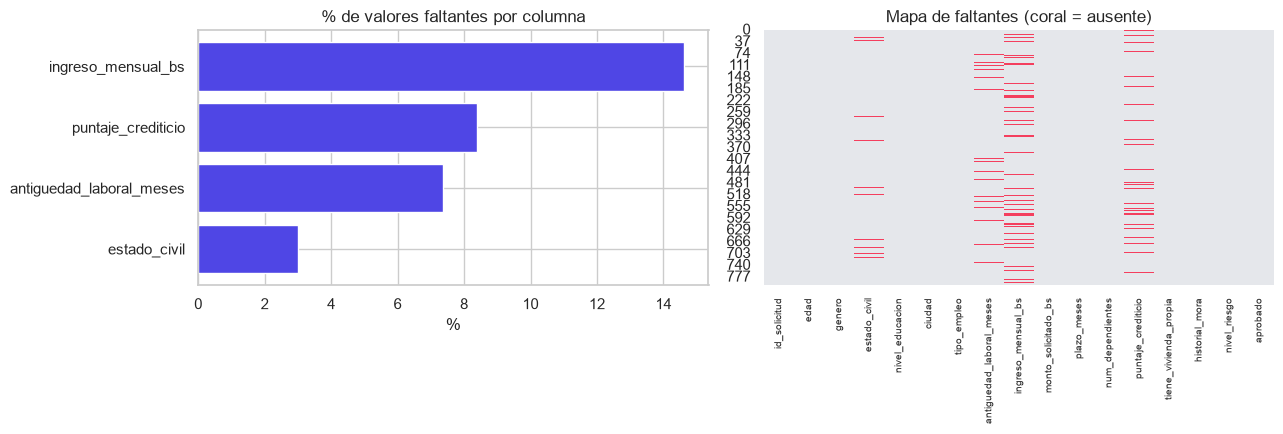

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pct = (df.isna().mean()*100)
pct = pct[pct > 0].sort_values()
axes[0].barh(pct.index, pct.values, color=INDIGO)
axes[0].set_title("% de valores faltantes por columna")
axes[0].set_xlabel("%")

sns.heatmap(df.isna(), cbar=False, cmap=["#E5E7EB", CORAL], ax=axes[1])
axes[1].set_title("Mapa de faltantes (coral = ausente)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, fontsize=7)
plt.tight_layout(); plt.show()

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 1.2 · Diagnosticar el mecanismo</div><div style="color:#111827;margin-top:4px">Para cada columna con faltantes, decide si es MCAR, MAR o estructural. <b>Pista:</b> cruza la ausencia contra <code>tipo_empleo</code>.</div></div>

**Solución**

In [26]:
# ¿La ausencia de 'ingreso_mensual_bs' depende del tipo de empleo?  -> MAR
tabla = df.assign(ingreso_falta=df["ingreso_mensual_bs"].isna())
print("P(ingreso faltante | tipo_empleo):")
print((tabla.groupby("tipo_empleo")["ingreso_falta"].mean()*100).round(1))
print()

# ¿'antiguedad_laboral_meses' falta SIEMPRE que está Desempleado?  -> estructural
print("Faltantes de antiguedad por tipo_empleo:")
print(df.groupby("tipo_empleo")["antiguedad_laboral_meses"]
        .apply(lambda s: f"{s.isna().mean()*100:.0f}% ({s.isna().sum()})"))

P(ingreso faltante | tipo_empleo):
tipo_empleo
Dependiente          7.0
Desempleado          3.4
Empleado Público     6.1
Independiente       35.3
Jubilado             3.8
Name: ingreso_falta, dtype: float64

Faltantes de antiguedad por tipo_empleo:
tipo_empleo
Dependiente            0% (0)
Desempleado         100% (59)
Empleado Público       0% (0)
Independiente          0% (0)
Jubilado               0% (0)
Name: antiguedad_laboral_meses, dtype: str


<div style="border-left:4px solid #6B7280;background:#F9FAFB;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#6B7280;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Nota · Lectura del resultado</div><div style="color:#111827;margin-top:4px"><code>ingreso_mensual_bs</code> falta mucho más en <b>Independientes</b> → <b>MAR</b> (imputar por grupo). <code>antiguedad_laboral_meses</code> falta en el 100% de los <b>Desempleados</b> → <b>estructural</b> (no tiene sentido imputar una mediana; el valor <em>no existe</em>). <code>puntaje_crediticio</code> falta de forma pareja → <b>MCAR</b>.</div></div>

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 1.3 · Imputar según el mecanismo</div><div style="color:#111827;margin-top:4px">Aplica una estrategia distinta a cada caso: mediana global (MCAR), mediana por grupo (MAR) y relleno con 0 + variable indicadora (estructural). Verifica que ya no queden faltantes.</div></div>

**Solución**

In [27]:
from sklearn.impute import SimpleImputer

df_imp = df.copy()

# (a) MCAR -> mediana global
imp_mediana = SimpleImputer(strategy="median")
df_imp["puntaje_crediticio"] = imp_mediana.fit_transform(df_imp[["puntaje_crediticio"]])

# (b) MAR -> mediana CONDICIONADA al tipo de empleo
df_imp["ingreso_mensual_bs"] = (
    df_imp.groupby("tipo_empleo")["ingreso_mensual_bs"]
          .transform(lambda s: s.fillna(s.median()))
)

# (c) Estructural -> el dato no existe: marca con indicador y rellena con 0
df_imp["sin_antiguedad"] = df_imp["antiguedad_laboral_meses"].isna().astype(int)
df_imp["antiguedad_laboral_meses"] = df_imp["antiguedad_laboral_meses"].fillna(0)

# (d) Categórica MCAR -> moda
df_imp["estado_civil"] = SimpleImputer(strategy="most_frequent") \
    .fit_transform(df_imp[["estado_civil"]]).ravel()

print("Faltantes restantes:", int(df_imp.isna().sum().sum()))

Faltantes restantes: 0


<div style="border-left:4px solid #F43F5E;background:#FEF2F2;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#F43F5E;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Cuidado · Error frecuente</div><div style="color:#111827;margin-top:4px">Imputar <code>antiguedad_laboral_meses</code> con la mediana metería ~200 meses de antigüedad a personas <b>desempleadas</b>: inventarías información falsa. La variable indicadora <code>sin_antiguedad</code> conserva la señal de que el dato no aplicaba.</div></div>

<h2 style="border-bottom:3px solid #4F46E5;padding-bottom:6px;color:#111827">
2.3.2 · Codificación de variables categóricas</h2>

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 2.1 · Limpiar antes de codificar</div><div style="color:#111827;margin-top:4px">Normaliza <code>estado_civil</code> y <code>tiene_vivienda_propia</code> para eliminar diferencias de mayúsculas/espacios. ¿Cuántas categorías únicas quedan antes y después?</div></div>

**Solución**

In [28]:
print("Antes  ->", df_imp["tiene_vivienda_propia"].nunique(), "categorías:",
      sorted(df_imp["tiene_vivienda_propia"].dropna().unique()))

df_imp["estado_civil"] = df_imp["estado_civil"].str.strip().str.title()
df_imp["tiene_vivienda_propia"] = (df_imp["tiene_vivienda_propia"]
                                   .str.strip().str.lower()
                                   .map({"sí":"Sí","si":"Sí","no":"No"}))

print("Después ->", df_imp["tiene_vivienda_propia"].nunique(), "categorías:",
      sorted(df_imp["tiene_vivienda_propia"].dropna().unique()))
print("estado_civil:", sorted(df_imp["estado_civil"].unique()))

Antes  -> 4 categorías: ['NO', 'No', 'Sí', 'si']
Después -> 2 categorías: ['No', 'Sí']
estado_civil: ['Casado', 'Divorciado', 'Soltero', 'Unión Libre', 'Viudo']


<div style="border-left:4px solid #7E22CE;background:#F5F3FF;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#7E22CE;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Definición · Nominal vs. Ordinal</div><div style="color:#111827;margin-top:4px"><b>Nominal</b>: categorías sin orden (ciudad, tipo de empleo) → <code>OneHotEncoder</code>. <b>Ordinal</b>: categorías con orden natural (nivel educativo, riesgo) → <code>OrdinalEncoder</code> con el orden declarado explícitamente. Codificar una nominal como ordinal le inventa un orden falso.</div></div>

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 2.2 · Codificar variables ordinales</div><div style="color:#111827;margin-top:4px">Codifica <code>nivel_educacion</code> y <code>nivel_riesgo</code> respetando su orden.</div></div>

**Solución**

In [29]:
from sklearn.preprocessing import OrdinalEncoder

orden_educacion = ["Primaria","Secundaria","Técnico","Licenciatura","Posgrado"]
orden_riesgo    = ["Bajo","Medio","Alto"]

ord_enc = OrdinalEncoder(categories=[orden_educacion, orden_riesgo])
df_imp[["educacion_cod","riesgo_cod"]] = ord_enc.fit_transform(
    df_imp[["nivel_educacion","nivel_riesgo"]])

df_imp[["nivel_educacion","educacion_cod","nivel_riesgo","riesgo_cod"]].head()

,nivel_educacion,educacion_cod,nivel_riesgo,riesgo_cod
0,Licenciatura,3.0,Bajo,0.0
1,Técnico,2.0,Alto,2.0
2,Posgrado,4.0,Alto,2.0
3,Licenciatura,3.0,Bajo,0.0
4,Secundaria,1.0,Bajo,0.0


<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 2.3 · Codificar variables nominales (one-hot)</div><div style="color:#111827;margin-top:4px">Aplica <code>OneHotEncoder</code> a <code>genero</code>, <code>estado_civil</code> y <code>tipo_empleo</code>. ¿Cuántas columnas nuevas se crean?</div></div>

**Solución**

In [30]:
from sklearn.preprocessing import OneHotEncoder

nominales = ["genero","estado_civil","tipo_empleo"]
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
mat = ohe.fit_transform(df_imp[nominales])
ohe_df = pd.DataFrame(mat, columns=ohe.get_feature_names_out(nominales), index=df_imp.index)

print("Columnas creadas:", ohe_df.shape[1])
ohe_df.head()

Columnas creadas: 12


,genero_Femenino,genero_Masculino,estado_civil_Casado,estado_civil_Divorciado,estado_civil_Soltero,estado_civil_Unión Libre,estado_civil_Viudo,tipo_empleo_Dependiente,tipo_empleo_Desempleado,tipo_empleo_Empleado Público,tipo_empleo_Independiente,tipo_empleo_Jubilado
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 2.4 · Alta cardinalidad: one-hot vs. frequency encoding</div><div style="color:#111827;margin-top:4px"><code>ciudad</code> tiene 15 categorías. Compara el costo en columnas de one-hot frente a un <em>frequency encoding</em> (una sola columna con la frecuencia de cada ciudad).</div></div>

**Solución**

In [31]:
# One-hot de ciudad -> muchas columnas
n_ohe_ciudad = df_imp["ciudad"].nunique()

# Frequency encoding -> una sola columna
frec = df_imp["ciudad"].value_counts(normalize=True)
df_imp["ciudad_frec"] = df_imp["ciudad"].map(frec)

print(f"One-hot de 'ciudad' -> {n_ohe_ciudad} columnas nuevas")
print("Frequency encoding  -> 1 columna")
df_imp[["ciudad","ciudad_frec"]].drop_duplicates().sort_values("ciudad_frec", ascending=False).head()

One-hot de 'ciudad' -> 15 columnas nuevas
Frequency encoding  -> 1 columna


,ciudad,ciudad_frec
2,La Paz,0.19625
1,Santa Cruz,0.18750
3,Cochabamba,0.14875
5,El Alto,0.13500
7,Potosí,0.07625


<div style="border-left:4px solid #6B7280;background:#F9FAFB;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#6B7280;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Nota · Criterio</div><div style="color:#111827;margin-top:4px">Con pocas categorías, one-hot es lo más seguro. Con alta cardinalidad (decenas o cientos), one-hot explota el número de columnas; ahí conviene <em>frequency</em>/<em>target encoding</em> o agrupar categorías raras en «Otros».</div></div>

<h2 style="border-bottom:3px solid #4F46E5;padding-bottom:6px;color:#111827">
2.3.3 · Escalado y normalización</h2>

<div style="border-left:4px solid #7E22CE;background:#F5F3FF;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#7E22CE;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Definición · Por qué escalar</div><div style="color:#111827;margin-top:4px">Modelos basados en distancias o gradientes (KNN, SVM, regresión logística, redes) se dejan dominar por las variables de mayor magnitud. <code>ingreso_mensual_bs</code> (hasta ~185.000) aplastaría a <code>edad</code> (18–70) si no se escalan a un rango comparable.</div></div>

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 3.1 · Comparar los tres escaladores</div><div style="color:#111827;margin-top:4px">Sobre <code>ingreso_mensual_bs</code> (que tiene <em>outliers</em>), compara <code>StandardScaler</code>, <code>MinMaxScaler</code> y <code>RobustScaler</code>. ¿Cuál resiste mejor los valores extremos?</div></div>

**Solución**

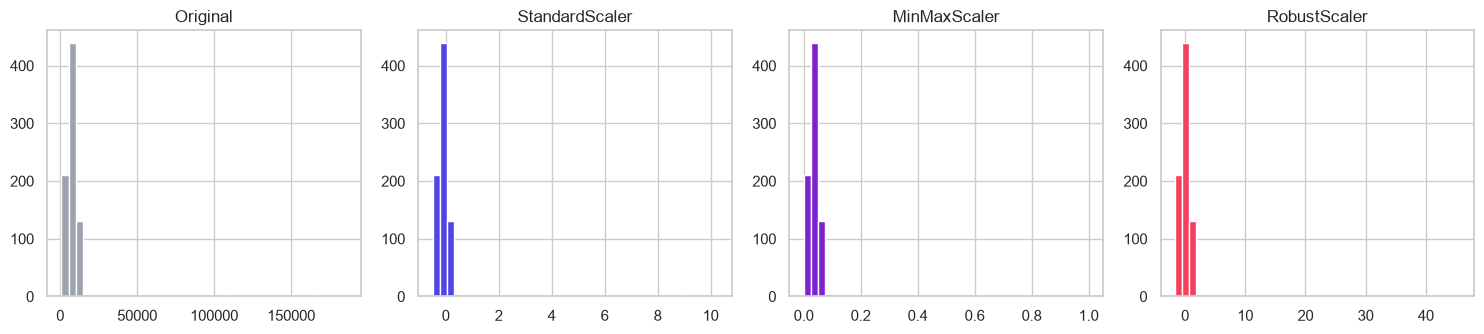

,StandardScaler,MinMaxScaler,RobustScaler
count,800.00,800.00,800.00
mean,0.00,0.05,0.48
std,1.00,0.09,4.40
min,-0.50,0.00,-1.70
25%,-0.24,0.02,-0.55
50%,-0.11,0.04,0.00
75%,-0.01,0.05,0.45
max,10.26,1.00,45.62


In [32]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

x = df_imp[["ingreso_mensual_bs"]].values
escaladores = {"StandardScaler":StandardScaler(),
               "MinMaxScaler":MinMaxScaler(),
               "RobustScaler":RobustScaler()}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
axes[0].hist(x, bins=40, color="#9CA3AF"); axes[0].set_title("Original")
for ax,(nombre,esc),col in zip(axes[1:], escaladores.items(), [INDIGO,PURPURA,CORAL]):
    ax.hist(esc.fit_transform(x), bins=40, color=col); ax.set_title(nombre)
plt.tight_layout(); plt.show()

resumen = pd.DataFrame({n: esc.fit_transform(x).ravel() for n,esc in escaladores.items()})
resumen.describe().round(2)

<div style="border-left:4px solid #6B7280;background:#F9FAFB;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#6B7280;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Nota · Lectura</div><div style="color:#111827;margin-top:4px">Los <em>outliers</em> comprimen a <code>MinMaxScaler</code> (casi todo cae cerca de 0) y estiran la desviación de <code>StandardScaler</code>. <code>RobustScaler</code> usa mediana y rango intercuartílico → mucho menos sensible a los extremos.</div></div>

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 3.2 · Escalar SIN fuga de datos</div><div style="color:#111827;margin-top:4px">Divide en train/test y ajusta (<code>fit</code>) el escalador <b>solo con train</b>. Explica por qué usar todo el dataset sería un error.</div></div>

**Solución**

In [33]:
from sklearn.model_selection import train_test_split

num_cols = ["edad","ingreso_mensual_bs","monto_solicitado_bs","puntaje_crediticio",
            "antiguedad_laboral_meses"]
X_tr, X_te = train_test_split(df_imp[num_cols], test_size=0.25,
                              random_state=42, stratify=df_imp["aprobado"])

sc = StandardScaler().fit(X_tr)          # <-- fit SOLO con train
X_tr_s = sc.transform(X_tr)
X_te_s = sc.transform(X_te)              # test se transforma con parámetros de train

print("Media aprendida (train):", sc.mean_.round(1))
print("Media del test tras escalar (no es exactamente 0, y está bien):",
      X_te_s.mean(axis=0).round(3))

Media aprendida (train): [4.46000e+01 8.77550e+03 5.66509e+04 6.55100e+02 2.36100e+02]
Media del test tras escalar (no es exactamente 0, y está bien): [-0.052  0.161  0.088 -0.094 -0.006]


<div style="border-left:4px solid #F43F5E;background:#FEF2F2;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#F43F5E;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Cuidado · Data leakage</div><div style="color:#111827;margin-top:4px">Si haces <code>fit</code> con todo el dataset, la media/desviación del <b>test</b> se filtra al entrenamiento y las métricas salen optimistas. El test debe simular datos <em>nunca vistos</em>.</div></div>

<h2 style="border-bottom:3px solid #4F46E5;padding-bottom:6px;color:#111827">
2.3.4 · Pipelines de transformación</h2>

<div style="border-left:4px solid #7E22CE;background:#F5F3FF;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#7E22CE;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Definición · Pipeline + ColumnTransformer</div><div style="color:#111827;margin-top:4px">Un <code>Pipeline</code> encadena pasos (imputar → escalar → modelar) en un solo objeto. Un <code>ColumnTransformer</code> aplica transformaciones <em>distintas</em> a distintos grupos de columnas. Juntos, todo el preprocesamiento se ajusta solo con train y se reaplica sin fuga.</div></div>

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 4.1 · Construir el pipeline completo</div><div style="color:#111827;margin-top:4px">Partiendo del CSV <b>crudo</b> (df original, con faltantes y texto sucio), arma un <code>ColumnTransformer</code> con tres ramas (numérica, nominal, ordinal) dentro de un <code>Pipeline</code> que termine en un clasificador, y evalúalo.</div></div>

**Solución** — partimos de nuevo desde el CSV crudo para que el pipeline haga *todo*.

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# --- Datos crudos ---
data = pd.read_csv("solicitudes_credito.csv")

# Limpieza mínima de texto sucio (esto NO lo hace el ColumnTransformer)
data["estado_civil"] = data["estado_civil"].str.strip().str.title()
data["tiene_vivienda_propia"] = (data["tiene_vivienda_propia"].str.strip().str.lower()
                                 .map({"sí":"Sí","si":"Sí","no":"No"}))

y = data["aprobado"]
X = data.drop(columns=["aprobado","id_solicitud"])

num_cols = ["edad","ingreso_mensual_bs","monto_solicitado_bs","puntaje_crediticio",
            "antiguedad_laboral_meses","num_dependientes","plazo_meses"]
nom_cols = ["genero","estado_civil","tipo_empleo","ciudad","tiene_vivienda_propia","historial_mora"]
ord_cols = ["nivel_educacion","nivel_riesgo"]

In [35]:
# --- Tres ramas de preprocesamiento ---
rama_num = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler()),
])
rama_nom = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])
rama_ord = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[orden_educacion, orden_riesgo],
                               handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocesador = ColumnTransformer([
    ("num", rama_num, num_cols),
    ("nom", rama_nom, nom_cols),
    ("ord", rama_ord, ord_cols),
])

modelo = Pipeline([
    ("preprocesamiento", preprocesador),
    ("clasificador", LogisticRegression(max_iter=1000)),
])
modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, d

In [36]:
# --- Entrenar y evaluar ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Rechazado","Aprobado"]))

              precision    recall  f1-score   support

   Rechazado       0.68      0.65      0.66       118
    Aprobado       0.52      0.55      0.54        82

    accuracy                           0.61       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.61      0.61      0.61       200



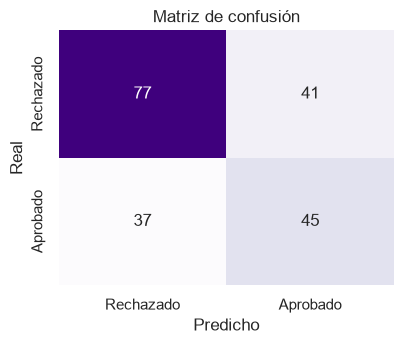

In [37]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["Rechazado","Aprobado"], yticklabels=["Rechazado","Aprobado"], ax=ax)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusión")
plt.tight_layout(); plt.show()

<div style="border-left:4px solid #6B7280;background:#F9FAFB;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#6B7280;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Nota · Lo importante del pipeline</div><div style="color:#111827;margin-top:4px">El objeto <code>modelo</code> guarda dentro de sí <b>todo</b>: imputación, escalado y codificación se ajustaron <em>solo con train</em> y se reaplican automáticamente al test y a cualquier dato futuro. Cero fuga, cero pasos manuales que olvidar.</div></div>

<div style="border-left:4px solid #4F46E5;background:linear-gradient(90deg,#EEF2FF,#F5F3FF);padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#4F46E5;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Ejercicio · 4.2 · Validación cruzada</div><div style="color:#111827;margin-top:4px">Estima el desempeño con validación cruzada de 5 particiones sobre el pipeline completo. ¿Por qué es seguro hacer CV con un pipeline y peligroso hacerlo con datos ya preprocesados a mano?</div></div>

**Solución**

In [38]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo, X, y, cv=5, scoring="f1")
print("F1 por partición:", scores.round(3))
print(f"F1 promedio: {scores.mean():.3f} ± {scores.std():.3f}")

F1 por partición: [0.641 0.552 0.585 0.558 0.647]
F1 promedio: 0.597 ± 0.040


<div style="border-left:4px solid #F43F5E;background:#FEF2F2;padding:10px 16px;border-radius:0 8px 8px 0;margin:6px 0;font-family:'IBM Plex Sans',Segoe UI,sans-serif"><div style="color:#F43F5E;font-weight:700;font-size:0.8rem;letter-spacing:.05em;text-transform:uppercase;font-family:'IBM Plex Mono',Consolas,monospace">Cuidado · Por qué el pipeline es clave en CV</div><div style="color:#111827;margin-top:4px">En cada partición de CV, el preprocesamiento se reajusta usando <b>solo</b> el train de esa partición. Si escalas/imputas <em>antes</em> de la CV, cada fold ya vio información del resto → fuga sutil que infla las métricas.</div></div>

<h2 style="color:#111827">Síntesis</h2>

| Subtema | Decisión clave | Herramienta |
|---|---|---|
| 2.3.1 Faltantes | La estrategia depende del **mecanismo** (MCAR/MAR/estructural) | `SimpleImputer`, imputación por grupo, indicador |
| 2.3.2 Codificación | Nominal → one-hot; ordinal → orden explícito; alta cardinalidad → frequency | `OneHotEncoder`, `OrdinalEncoder` |
| 2.3.3 Escalado | Con *outliers* → `RobustScaler`; siempre `fit` solo con train | `StandardScaler`, `MinMaxScaler`, `RobustScaler` |
| 2.3.4 Pipelines | Todo el preprocesamiento vive dentro del `Pipeline` → sin fuga | `Pipeline`, `ColumnTransformer` |
